# 01. Exploratory Data Analysis (EDA)

In this notebook we perform a thorough exploration of the water consumption dataset to understand regional trends, seasonal patterns, consumption distributions, and potential data quality issues before building any forecasting models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

## 1.1 Load the Raw Dataset

In [2]:
df = pd.read_csv("../Dataset/raw/water_consumption_forecasting.csv")
df["date"] = pd.to_datetime(df["date"])
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df.date.min()} to {df.date.max()}")
print(f"Regions: {df.region.unique()}")
df.head(10)

Dataset shape: (900, 3)
Date range: 2023-01-01 00:00:00 to 2023-06-29 00:00:00
Regions: ['North' 'South' 'East' 'West' 'Central']


,region,date,consumption_liters
0,North,2023-01-01,11673.07
1,North,2023-01-02,14736.03
2,North,2023-01-03,19370.75
3,North,2023-01-04,17774.55
4,North,2023-01-05,14972.58
5,North,2023-01-06,8077.63
6,North,2023-01-07,12822.42
7,North,2023-01-08,14137.49
8,North,2023-01-09,7607.32
9,North,2023-01-10,9191.87


## 1.2 Data Quality Check
We inspect for missing values, duplicates, and data type consistency.

In [3]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Duplicate Rows ===")
print(f"Number of duplicates: {df.duplicated().sum()}")
print("\n=== Records per Region ===")
print(df["region"].value_counts())

=== Data Types ===
region                        object
date                  datetime64[ns]
consumption_liters           float64
dtype: object

=== Missing Values ===
region                0
date                  0
consumption_liters    0
dtype: int64

=== Duplicate Rows ===
Number of duplicates: 0

=== Records per Region ===
region
North      180
South      180
East       180
West       180
Central    180
Name: count, dtype: int64


## 1.3 Summary Statistics
Looking at the central tendency and spread of consumption across all regions.

In [4]:
df.describe()

,date,consumption_liters
count,900,900.000000
mean,2023-03-31 11:59:59.999999744,12753.758211
min,2023-01-01 00:00:00,5004.090000
25%,2023-02-14 18:00:00,9187.247500
50%,2023-03-31 12:00:00,13045.510000
75%,2023-05-15 06:00:00,16365.062500
max,2023-06-29 00:00:00,19989.830000
std,NaN,4278.566391


## 1.4 Per-Region Summary Statistics
Breaking down the statistics by each region to see if some regions have higher baselines.

In [5]:
df.groupby("region")["consumption_liters"].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
Central,180.0,13040.439889,4044.777173,5067.01,9771.9925,13584.495,16431.3125,19739.44
East,180.0,13102.412611,4169.992765,5014.83,9827.5325,13237.945,16517.4575,19989.83
North,180.0,12791.649667,4316.595249,5063.96,9152.1800,12970.820,16365.7225,19892.73
South,180.0,12350.685833,4492.796524,5027.73,8678.4625,12811.250,16166.2775,19975.27
West,180.0,12483.603056,4350.787898,5004.09,8708.0625,12947.130,16275.6475,19906.71


## 1.5 Distribution of Daily Consumption
Plotting the overall histogram and KDE to understand the shape of the distribution.

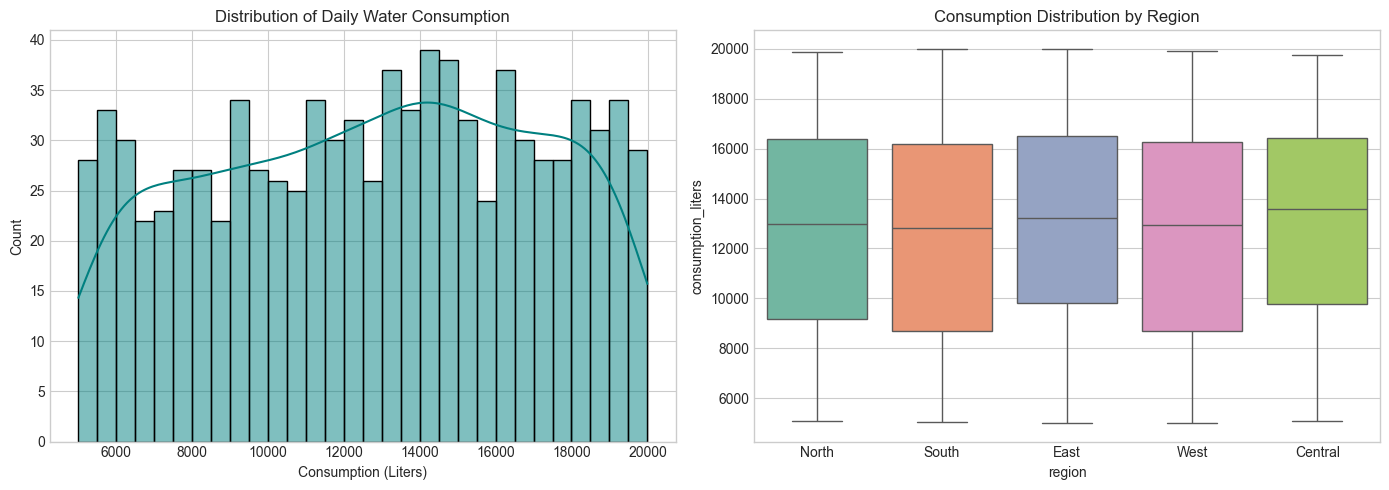

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["consumption_liters"], bins=30, kde=True, color="teal", ax=axes[0])
axes[0].set_title("Distribution of Daily Water Consumption")
axes[0].set_xlabel("Consumption (Liters)")

sns.boxplot(data=df, x="region", y="consumption_liters", palette="Set2", ax=axes[1])
axes[1].set_title("Consumption Distribution by Region")

plt.tight_layout()
plt.show()

## 1.6 Time-Series Trends by Region
Plotting consumption over time for each region to visually identify trends and seasonality.

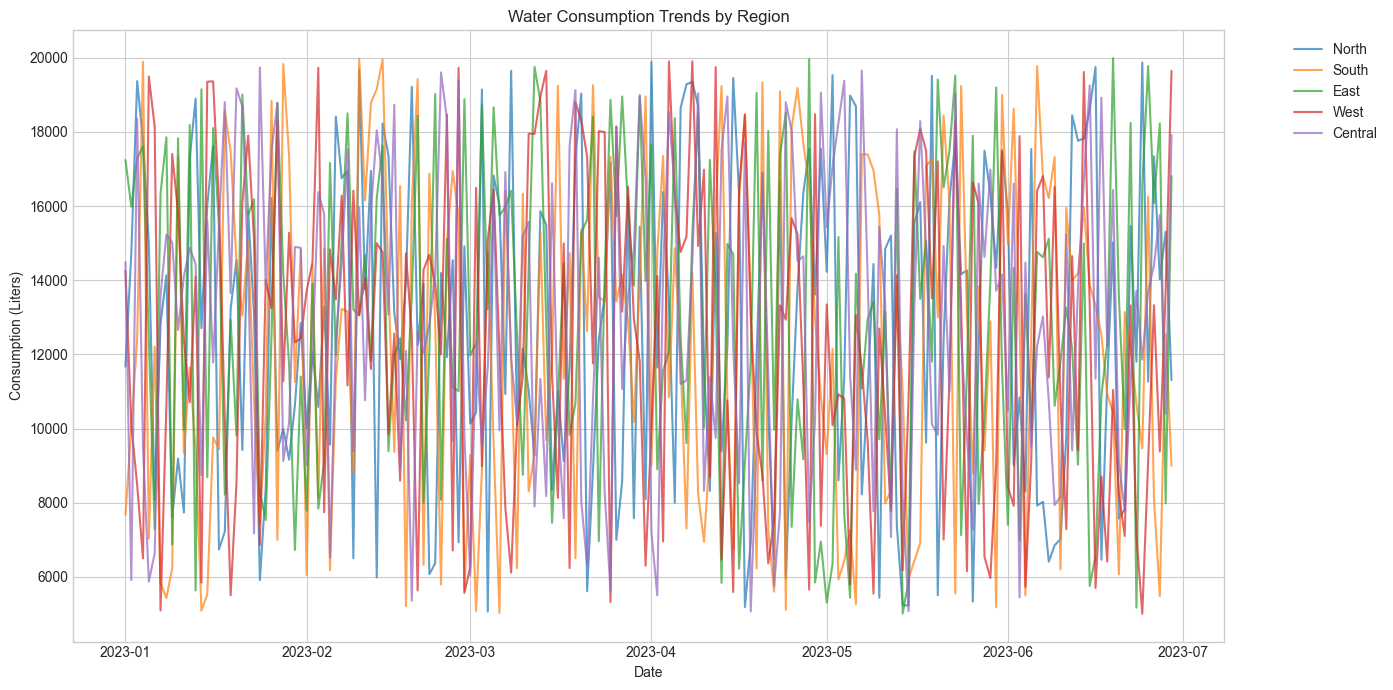

In [7]:
plt.figure(figsize=(14, 7))
for region in df["region"].unique():
    region_data = df[df["region"] == region]
    plt.plot(region_data["date"], region_data["consumption_liters"], label=region, alpha=0.7)
plt.title("Water Consumption Trends by Region")
plt.xlabel("Date")
plt.ylabel("Consumption (Liters)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 1.7 Day-of-Week Analysis
Checking whether consumption patterns differ on weekdays vs weekends.

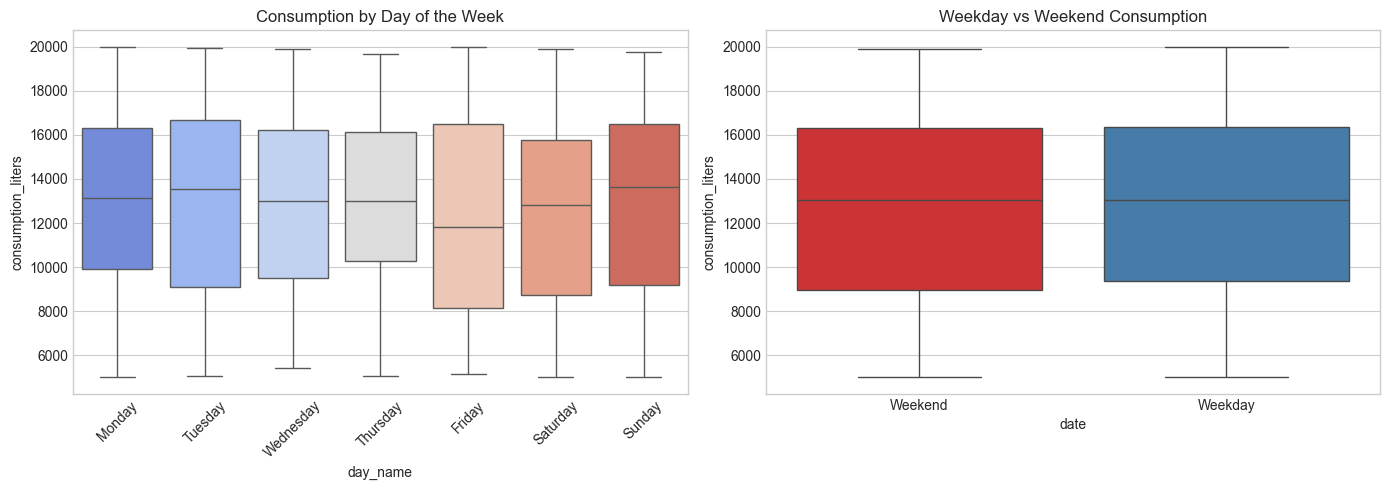

In [8]:
df["day_name"] = df["date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="day_name", y="consumption_liters", order=order, palette="coolwarm", ax=axes[0])
axes[0].set_title("Consumption by Day of the Week")
axes[0].tick_params(axis="x", rotation=45)

weekend_flag = df["date"].dt.dayofweek.isin([5, 6]).map({True: "Weekend", False: "Weekday"})
sns.boxplot(x=weekend_flag, y=df["consumption_liters"], palette="Set1", ax=axes[1])
axes[1].set_title("Weekday vs Weekend Consumption")

plt.tight_layout()
plt.show()

## 1.8 Monthly Trend Analysis

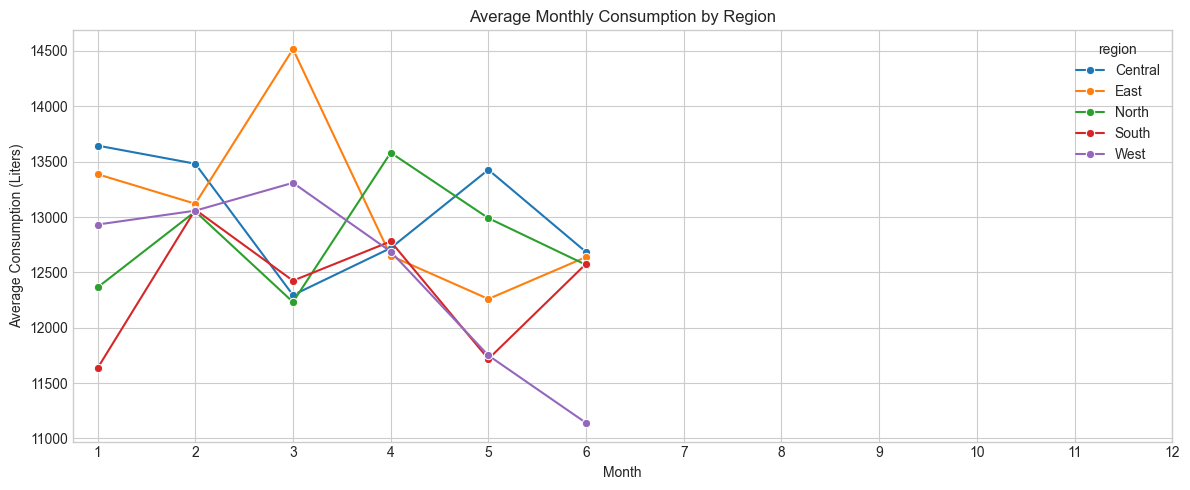

In [9]:
df["month"] = df["date"].dt.month
monthly_avg = df.groupby(["month", "region"])["consumption_liters"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_avg, x="month", y="consumption_liters", hue="region", marker="o")
plt.title("Average Monthly Consumption by Region")
plt.xlabel("Month")
plt.ylabel("Average Consumption (Liters)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 1.9 Correlation Heatmap
Checking correlations between numeric features.

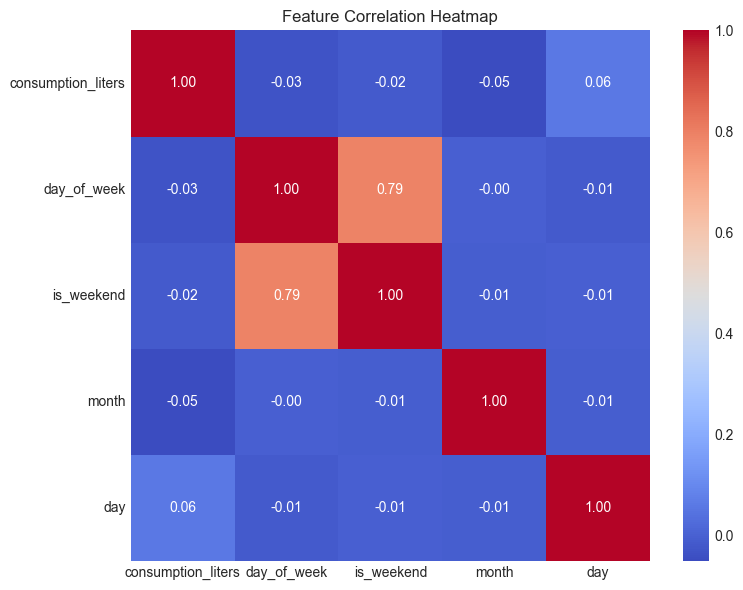

In [10]:
df["day_of_week"] = df["date"].dt.dayofweek
df["day"] = df["date"].dt.day
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

corr_cols = ["consumption_liters", "day_of_week", "is_weekend", "month", "day"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 1.10 Key Findings

- The dataset is clean with **no missing values** and **no duplicates**.
- Daily consumption ranges from ~5,000L to ~20,000L with a fairly uniform distribution.
- All 5 regions show similar consumption ranges and parallel temporal trends.
- No strong weekday vs weekend effect is visible, but subtle patterns may exist.
- Month-level analysis shows some variation that could represent seasonal effects.
- These insights will guide our feature engineering in the next notebook.